In [2]:
print("hello, I'm starting my data analytics project")

hello, I'm starting my data analytics project


In [4]:
import pandas as pd

df = pd.read_csv('survey_2014_aggregated.csv')
df.head()

,question_id,question_text,response_category,respondent_count,percent
0,Q1,What is your age group?,Less than 25,10,10
1,Q1,What is your age group?,26-40,40,40
2,Q1,What is your age group?,41-50,35,35
3,Q1,What is your age group?,Above 50,15,15
4,Q2,What is your annual income?,2-6 lakhs,30,30


In [6]:
df.shape

(67, 5)

In [8]:
df.columns

Index(['question_id', 'question_text', 'response_category', 'respondent_count',
       'percent'],
      dtype='object')

In [10]:
df['question_id'].unique()

array(['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11',
       'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18'], dtype=object)

In [12]:
df['question_id'] == 'Q4'

,question_id
0,False
1,False
2,False
3,False
4,False
...,...
62,False
63,False
64,False
65,False


In [14]:
q4 = df[df['question_id'] == 'Q4']
q4

,question_id,question_text,response_category,respondent_count,percent
10,Q4,Which media gets your attention?,Printed media,20,20
11,Q4,Which media gets your attention?,Television,10,10
12,Q4,Which media gets your attention?,Internet,30,30
13,Q4,Which media gets your attention?,Radio,10,10
14,Q4,Which media gets your attention?,Other,30,30


In [17]:
q4.sort_values('respondent_count', ascending=False)


,question_id,question_text,response_category,respondent_count,percent
12,Q4,Which media gets your attention?,Internet,30,30
14,Q4,Which media gets your attention?,Other,30,30
10,Q4,Which media gets your attention?,Printed media,20,20
11,Q4,Which media gets your attention?,Television,10,10
13,Q4,Which media gets your attention?,Radio,10,10


In [19]:
df['question_id'] == 'Q15'

,question_id
0,False
1,False
2,False
3,False
4,False
...,...
62,False
63,False
64,False
65,False


In [21]:
q15 = df[df['question_id'] == 'Q15']
q15

,question_id,question_text,response_category,respondent_count,percent
47,Q15,Which media would be most helpful for getting ...,TV ads,15,15
48,Q15,Which media would be most helpful for getting ...,Hoardings,20,20
49,Q15,Which media would be most helpful for getting ...,Printed media,25,25
50,Q15,Which media would be most helpful for getting ...,Internet,35,35
51,Q15,Which media would be most helpful for getting ...,Others,15,15


In [24]:
q15.sort_values('respondent_count', ascending=False)

,question_id,question_text,response_category,respondent_count,percent
50,Q15,Which media would be most helpful for getting ...,Internet,35,35
49,Q15,Which media would be most helpful for getting ...,Printed media,25,25
48,Q15,Which media would be most helpful for getting ...,Hoardings,20,20
47,Q15,Which media would be most helpful for getting ...,TV ads,15,15
51,Q15,Which media would be most helpful for getting ...,Others,15,15


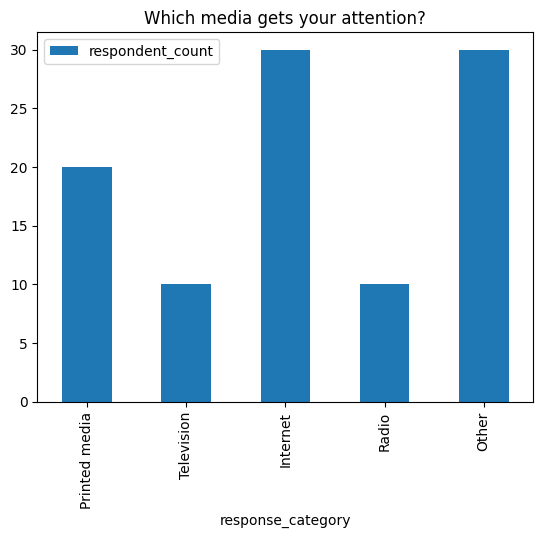

In [26]:
import matplotlib.pyplot as plt

q4.plot(x='response_category', y='respondent_count', kind='bar')
plt.title('Which media gets your attention?')
plt.show()

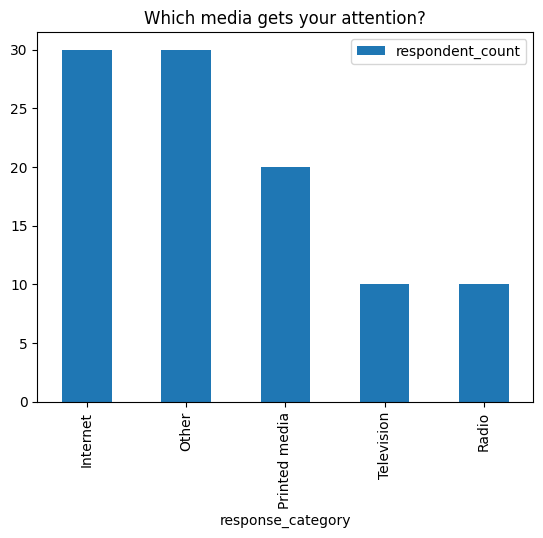

In [28]:
q4.sort_values('respondent_count', ascending=False).plot(x='response_category', y='respondent_count', kind='bar')
plt.title('Which media gets your attention?')
plt.show()

In [30]:
q17_18 = df[df['question_id'].isin(['Q17', 'Q18'])]
q17_18

,question_id,question_text,response_category,respondent_count,percent
57,Q17,Are you satisfied with the advertisements prom...,Excellent,10,10
58,Q17,Are you satisfied with the advertisements prom...,Good,20,20
59,Q17,Are you satisfied with the advertisements prom...,Average,25,25
60,Q17,Are you satisfied with the advertisements prom...,Not good,30,30
61,Q17,Are you satisfied with the advertisements prom...,Poor,15,15
62,Q18,Are you satisfied with the advertisement effor...,Excellent,20,20
63,Q18,Are you satisfied with the advertisement effor...,Good,30,30
64,Q18,Are you satisfied with the advertisement effor...,Average,27,27
65,Q18,Are you satisfied with the advertisement effor...,Not good,13,13
66,Q18,Are you satisfied with the advertisement effor...,Poor,10,10


In [32]:
comparison = q17_18.pivot(index='response_category', columns='question_id', values='respondent_count')
comparison


question_id,Q17,Q18
response_category,,
Average,25,27
Excellent,10,20
Good,20,30
Not good,30,13
Poor,15,10


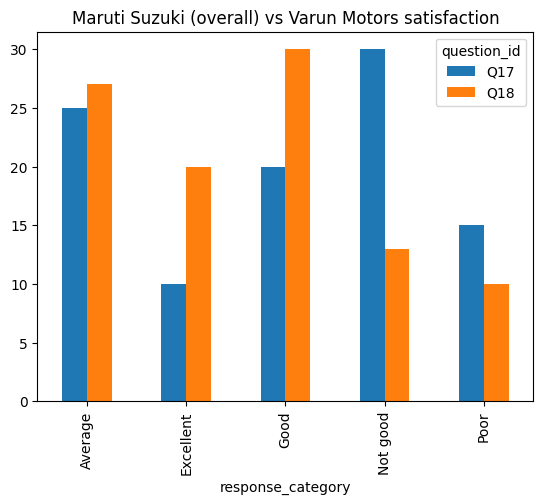

In [34]:
comparison.plot(kind='bar')
plt.title('Maruti Suzuki (overall) vs Varun Motors satisfaction')
plt.show()

In [38]:
comparison['pct_positive'] = (comparison['Q17'] + comparison['Q18'])
comparison.loc[['Excellent','Good']].sum()


,0
question_id,
Q17,30
Q18,50
pct_positive,80


In [40]:
q4_15 = df[df['question_id'].isin(['Q4', 'Q15'])]
q4_15

,question_id,question_text,response_category,respondent_count,percent
10,Q4,Which media gets your attention?,Printed media,20,20
11,Q4,Which media gets your attention?,Television,10,10
12,Q4,Which media gets your attention?,Internet,30,30
13,Q4,Which media gets your attention?,Radio,10,10
14,Q4,Which media gets your attention?,Other,30,30
47,Q15,Which media would be most helpful for getting ...,TV ads,15,15
48,Q15,Which media would be most helpful for getting ...,Hoardings,20,20
49,Q15,Which media would be most helpful for getting ...,Printed media,25,25
50,Q15,Which media would be most helpful for getting ...,Internet,35,35
51,Q15,Which media would be most helpful for getting ...,Others,15,15


In [42]:
comparison = q4_15.pivot(index='response_category', columns='question_id', values='respondent_count')
comparison

question_id,Q15,Q4
response_category,,
Hoardings,20.0,NaN
Internet,35.0,30.0
Other,NaN,30.0
Others,15.0,NaN
Printed media,25.0,20.0
Radio,NaN,10.0
TV ads,15.0,NaN
Television,NaN,10.0


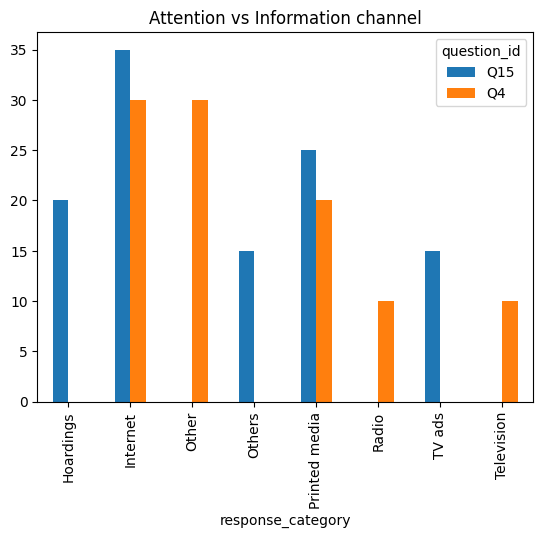

In [44]:
q4_15 = df[df['question_id'].isin(['Q4', 'Q15'])]
comp2 = q4_15.pivot(index='response_category', columns='question_id', values='respondent_count')
comp2.plot(kind='bar')
plt.title('Attention vs Information channel')
plt.show()